## This notebook is EDA on PhotoSynthesis Dataset


importing Necessary libraries

In [1]:
import pandas as pd
import seaborn as sns
import plotly.express as px
print('libraries are imported sucessfully')

libraries are imported sucessfully


In [2]:
df = pd.read_csv('Photosynthesis.csv')
print('Dataset is Loadded is sucessfully !!!')


Dataset is Loadded is sucessfully !!!


In [3]:
df.head(10)

,year,block,P addition (g P m-2 yr-1),N addition (g N m-2 yr-1),name,ANPP (g m-2 yr-1),leaf N:P ratio
0,2020,1,0,0,2020103,"84,911","11,48002347"
1,2020,1,10,10,2020105,"67,391","9,66734798"
2,2020,1,0,10,2020109,"173,024","16,37606087"
3,2020,1,10,0,2020116,"115,431","4,102130003"
4,2020,2,10,0,2020203,"86,125","4,490384489"
5,2020,2,0,10,2020210,"170,709","16,68709896"
6,2020,2,0,0,2020215,"70,337","11,86325266"
7,2020,2,10,10,2020220,"145,69","8,60955077"
8,2020,3,10,0,2020303,"75,317","4,024889632"
9,2020,3,10,10,2020308,"101,55","7,644888591"


In [4]:
#Dataset Information

print(df.info())
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 60 entries, 0 to 59
Data columns (total 7 columns):
 #   Column                     Non-Null Count  Dtype
---  ------                     --------------  -----
 0   year                       60 non-null     int64
 1   block                      60 non-null     int64
 2   P addition (g P m-2 yr-1)  60 non-null     int64
 3   N addition (g N m-2 yr-1)  60 non-null     int64
 4   name                       60 non-null     int64
 5   ANPP (g m-2 yr-1)          60 non-null     str  
 6   leaf N:P ratio             60 non-null     str  
dtypes: int64(5), str(2)
memory usage: 3.4 KB
None


,year,block,P addition (g P m-2 yr-1),N addition (g N m-2 yr-1),name
count,60.000000,60.000000,60.000000,60.000000,6.000000e+01
mean,2021.000000,3.000000,5.000000,5.000000,2.021312e+06
std,0.823387,1.426148,5.042195,5.042195,8.360354e+02
min,2020.000000,1.000000,0.000000,0.000000,2.020103e+06
25%,2020.000000,2.000000,0.000000,0.000000,2.020421e+06
50%,2021.000000,3.000000,5.000000,5.000000,2.021310e+06
75%,2022.000000,4.000000,10.000000,10.000000,2.022205e+06
max,2022.000000,5.000000,10.000000,10.000000,2.022523e+06


In [5]:
df['year']

0     2020
1     2020
2     2020
3     2020
4     2020
5     2020
6     2020
7     2020
8     2020
9     2020
10    2020
11    2020
12    2020
13    2020
14    2020
15    2020
16    2020
17    2020
18    2020
19    2020
20    2021
21    2021
22    2021
23    2021
24    2021
25    2021
26    2021
27    2021
28    2021
29    2021
30    2021
31    2021
32    2021
33    2021
34    2021
35    2021
36    2021
37    2021
38    2021
39    2021
40    2022
41    2022
42    2022
43    2022
44    2022
45    2022
46    2022
47    2022
48    2022
49    2022
50    2022
51    2022
52    2022
53    2022
54    2022
55    2022
56    2022
57    2022
58    2022
59    2022
Name: year, dtype: int64

In [6]:
df['leaf N:P ratio'].head(5)

0    11,48002347
1     9,66734798
2    16,37606087
3    4,102130003
4    4,490384489
Name: leaf N:P ratio, dtype: str

#### Data formatting 

In [7]:
df['ANPP (g m-2 yr-1)'] = df['ANPP (g m-2 yr-1)'].str.replace(',','')
df['ANPP (g m-2 yr-1)'] = df['ANPP (g m-2 yr-1)'].astype(int)


df['leaf N:P ratio'] = df['leaf N:P ratio'].str.replace(',','')
df['leaf N:P ratio'] = df['leaf N:P ratio'].astype(int
)



# Convert 'name' column into a proper Datetime format
date_str = df['name'].astype(str)
years = date_str.str[:4]
days = date_str.str[-2:]
months = date_str.str[4:-2].str.zfill(2)
df['date'] = pd.to_datetime(years + '-' + months + '-' + days)


## EDA

#### Distributional Analysis
##### **Simple Distributional Analysis**  

<Axes: xlabel='year', ylabel='Count'>

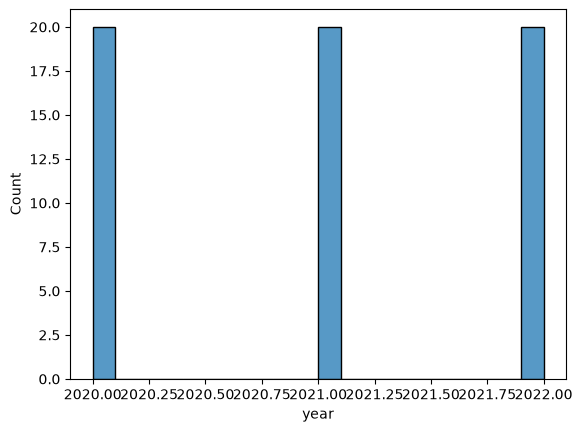

In [8]:
sns.histplot(data=df,x='year',bins=20)

In [9]:
fig_a = px.histogram(df, x='year',nbins=5)
fig_a.show()

In [10]:
fig_b = px.histogram(df, x='block')
fig_b.show()

In [11]:
fig_c = px.histogram(df, x='P addition (g P m-2 yr-1)',nbins=20)
fig_c.show()

In [12]:
fig_d =px.histogram(df,x='N addition (g N m-2 yr-1)',nbins=20)
fig_d.show()

#### Relational Analysis

In [13]:
# Direct month name extraction without mapping
df['month'] = df['date'].dt.strftime('%b')  # Generates 'Jan', 'Feb', 'Mar'...

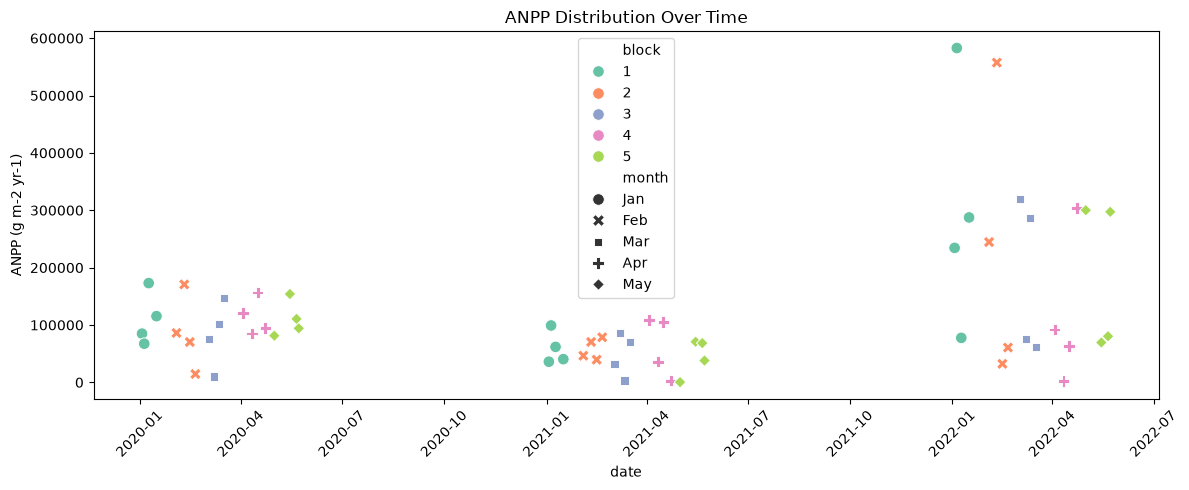

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 5))
sns.scatterplot(
    data=df, 
    x='date', 
    y='ANPP (g m-2 yr-1)', 
    hue='block',
    style='month',          
    palette='Set2', 
    s=70                  # Marker size
)

plt.xticks(rotation=45)
plt.title('ANPP Distribution Over Time')
plt.tight_layout()
plt.show()

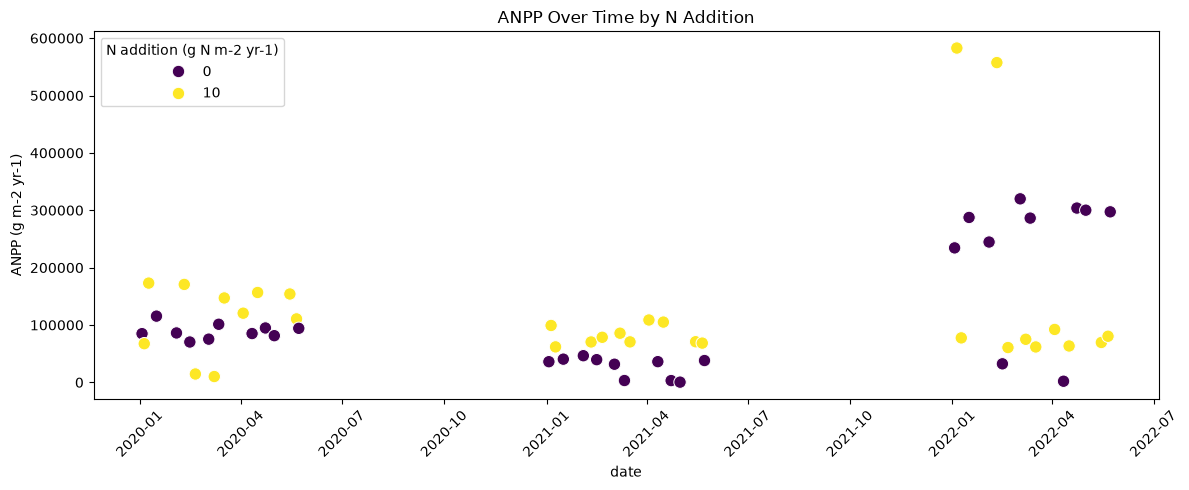

In [15]:
plt.figure(figsize=(12, 5))
sns.scatterplot(
    data=df,
    x='date',
    y='ANPP (g m-2 yr-1)',
    hue='N addition (g N m-2 yr-1)',  # Primary factor (Color)                     # Secondary factor (Marker shape)
    palette='viridis',
    s=80
)

plt.xticks(rotation=45)
plt.title('ANPP Over Time by N Addition')
plt.tight_layout()
plt.show()